# 🏭 Manufacturing Defect Prediction — ML Pipeline

---

> **Purpose:** This notebook trains and evaluates three machine learning models to predict product defects on the manufacturing line. It outputs a risk-scored CSV ready for reporting, dashboarding, or operational review.

---

## 📋 Quick Reference

| Item | Detail |
|---|---|
| **Target Variable** | `Defect` — 0 = No Defect, 1 = Defect |
| **Models Trained** | Logistic Regression · Random Forest · Gradient Boosting |
| **Selection Method** | Best ROC-AUC score (auto-selected) |
| **Output File** | `manufacturing_predictions.csv` |
| **Estimated Runtime** | 1–3 minutes (standard dataset) |

---

## 🔢 Output Columns Explained

| Column | Description |
|---|---|
| `Predicted_Defect` | Binary prediction — 0 = No Defect, 1 = Defect |
| `Defect_Probability` | Model confidence score between 0.00 and 1.00 |
| `Risk_Category` | **Low** < 30% · **Medium** 30–60% · **High** > 60% |

---

## 🗂️ Notebook Structure

| Cell | What It Does |
|---|---|
| **Cell 1** | Dataset import |
| **Cell 2** | Library imports |
| **Cell 3** | Data preview & column inspection |
| **Cell 4** | Exploratory data analysis (EDA) + visualisations |
| **Cell 5** | Preprocessing — missing values, encoding, train/test split |
| **Cell 6** | Model training (all 3 models) + evaluation metrics |
| **Cell 7** | Confusion matrices + ROC curve comparison |
| **Cell 8** | Best model selection + feature importance |
| **Cell 9** | Full dataset predictions + CSV export |
| **Cell 10** | Risk category visualisations |

---

## ⚠️ Before You Run

- ✅ Ensure the dataset is loaded in **Cell 1** and the dataframe is named **`df`**
- ✅ The `Defect` column must exist and contain binary values (0 / 1)
- ✅ Run cells **in order** — each cell depends on the one above
- ✅ When Cell 9 runs, your browser will **automatically download** `manufacturing_predictions.csv`

---

## 📊 How To Interpret Results

**ROC-AUC Score** is the primary metric used to select the best model.
A score of 0.5 = no better than random guessing. A score of 1.0 = perfect prediction.
Anything above **0.80 is considered strong** for manufacturing defect use cases.

**Risk Categories** are designed for operational use:
- 🟢 **Low** — Unit is very unlikely to be defective. No action needed.
- 🟡 **Medium** — Unit warrants a manual spot-check before shipping.
- 🔴 **High** — Unit should be flagged for inspection or removed from the line.

---

*Built with scikit-learn · pandas · matplotlib · seaborn*
*Model auto-selection based on cross-validated ROC-AUC · Export via google.colab.files*

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/predicting-manufacturing-defects-dataset")

print("Path to dataset files:", path)

100%|██████████| 363k/363k [00:00<00:00, 13.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rabieelkharoua/predicting-manufacturing-defects-dataset/versions/1


In [2]:
# CELL 2 — Install & Import Libraries
# !pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from google.colab import files

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
# CELL 3 — Preview & Understand the Data

# Replace 'df' with whatever your variable name is from Cell 1
# Common names: df, data, manufacturing_data, dataset

# --- Auto-detect your dataframe name if needed ---
import os
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_file_path)
    print(f"Loaded '{csv_files[0]}' into DataFrame 'df'.")
else:
    print("No CSV files found in the dataset directory.")

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Loaded 'manufacturing_defect_dataset.csv' into DataFrame 'df'.
Shape: (3240, 17)

Column names:
 ['ProductionVolume', 'ProductionCost', 'SupplierQuality', 'DeliveryDelay', 'DefectRate', 'QualityScore', 'MaintenanceHours', 'DowntimePercentage', 'InventoryTurnover', 'StockoutRate', 'WorkerProductivity', 'SafetyIncidents', 'EnergyConsumption', 'EnergyEfficiency', 'AdditiveProcessTime', 'AdditiveMaterialCost', 'DefectStatus']

Data types:
 ProductionVolume          int64
ProductionCost          float64
SupplierQuality         float64
DeliveryDelay             int64
DefectRate              float64
QualityScore            float64
MaintenanceHours          int64
DowntimePercentage      float64
InventoryTurnover       float64
StockoutRate            float64
WorkerProductivity      float64
SafetyIncidents           int64
EnergyConsumption       float64
EnergyEfficiency        float64
AdditiveProcessTime     float64
AdditiveMaterialCost    float64
DefectStatus              int64
dtype: object

F

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1


=== Missing Values ===
ProductionVolume        0
ProductionCost          0
SupplierQuality         0
DeliveryDelay           0
DefectRate              0
QualityScore            0
MaintenanceHours        0
DowntimePercentage      0
InventoryTurnover       0
StockoutRate            0
WorkerProductivity      0
SafetyIncidents         0
EnergyConsumption       0
EnergyEfficiency        0
AdditiveProcessTime     0
AdditiveMaterialCost    0
DefectStatus            0
dtype: int64

=== Target Distribution ===
DefectStatus
1    2723
0     517
Name: count, dtype: int64

Defect rate: 84.04%


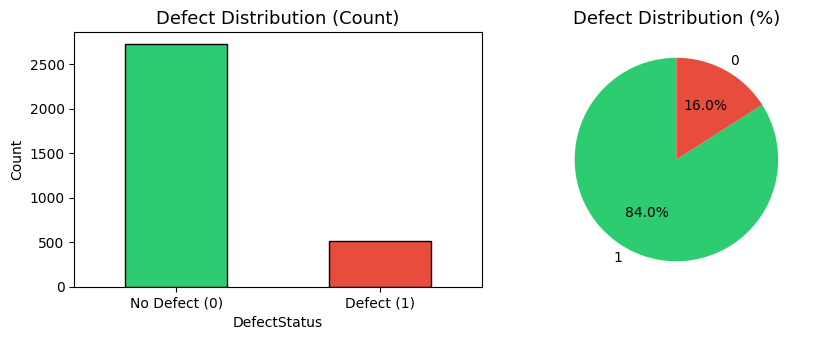

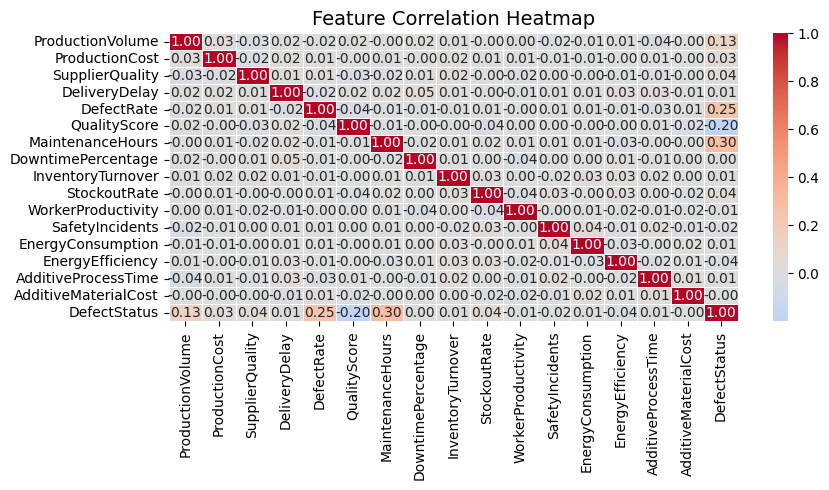

In [14]:
# CELL 4 — Exploratory Data Analysis (EDA)

print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Distribution ===")
print(df['DefectStatus'].value_counts())
print(f"\nDefect rate: {df['DefectStatus'].mean()*100:.2f}%")

# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

df['DefectStatus'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'],
                                  edgecolor='black')
axes[0].set_title('Defect Distribution (Count)', fontsize=13)
axes[0].set_xticklabels(['No Defect (0)', 'Defect (1)'], rotation=0)
axes[0].set_ylabel('Count')

df['DefectStatus'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                  colors=['#2ecc71','#e74c3c'], startangle=90)
axes[1].set_title('Defect Distribution (%)', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Correlation heatmap (numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(9, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# CELL 5 — Data Preprocessing

df_model = df.copy()

# --- Handle missing values ---
for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        df_model[col].fillna(df_model[col].median(), inplace=True)
    else:
        df_model[col].fillna(df_model[col].mode()[0], inplace=True)

# --- Encode categorical columns ---
label_encoders = {}
cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
if 'DefectStatus' in cat_cols: # Changed 'Defect' to 'DefectStatus'
    cat_cols.remove('DefectStatus') # Changed 'Defect' to 'DefectStatus'

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"  Encoded: {col}")

# --- Define features and target ---
TARGET = 'DefectStatus' # Changed 'Defect' to 'DefectStatus'
FEATURES = [col for col in df_model.columns if col != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"\n✅ Features ({len(FEATURES)}): {FEATURES}")
print(f"✅ Target: {TARGET}")
print(f"✅ Dataset shape: X={X.shape}, y={y.shape}")

# --- Train / Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Scale features (important for Logistic Regression) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


✅ Features (16): ['ProductionVolume', 'ProductionCost', 'SupplierQuality', 'DeliveryDelay', 'DefectRate', 'QualityScore', 'MaintenanceHours', 'DowntimePercentage', 'InventoryTurnover', 'StockoutRate', 'WorkerProductivity', 'SafetyIncidents', 'EnergyConsumption', 'EnergyEfficiency', 'AdditiveProcessTime', 'AdditiveMaterialCost']
✅ Target: DefectStatus
✅ Dataset shape: X=(3240, 16), y=(3240,)

✅ Train size: 2592 | Test size: 648


In [6]:
# CELL 6 — Train All Three Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, max_depth=10,
                                                    random_state=42, n_jobs=-1),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                        max_depth=4, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")

    # Use scaled data for Logistic Regression, raw for tree models
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled  if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)

    y_pred      = model.predict(X_te)
    y_prob      = model.predict_proba(X_te)[:, 1]
    roc_auc     = roc_auc_score(y_test, y_prob)
    cv_scores   = cross_val_score(model, X_tr, y_train, cv=5, scoring='roc_auc')

    results[name] = {
        'model':   model,
        'y_pred':  y_pred,
        'y_prob':  y_prob,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std()
    }

    print(f"\n📊 Classification Report:\n{classification_report(y_test, y_pred)}")
    print(f"🎯 ROC-AUC Score:      {roc_auc:.4f}")
    print(f"🔁 CV ROC-AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



  Training: Logistic Regression

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.38      0.49       103
           1       0.89      0.97      0.93       545

    accuracy                           0.88       648
   macro avg       0.80      0.67      0.71       648
weighted avg       0.86      0.88      0.86       648

🎯 ROC-AUC Score:      0.7960
🔁 CV ROC-AUC (5-fold): 0.8465 ± 0.0046

  Training: Random Forest

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.73      0.82       103
           1       0.95      0.99      0.97       545

    accuracy                           0.95       648
   macro avg       0.95      0.86      0.90       648
weighted avg       0.95      0.95      0.95       648

🎯 ROC-AUC Score:      0.8209
🔁 CV ROC-AUC (5-fold): 0.8930 ± 0.0217

  Training: Gradient Boosting

📊 Classification Report:
              precision    recall  f1-sco

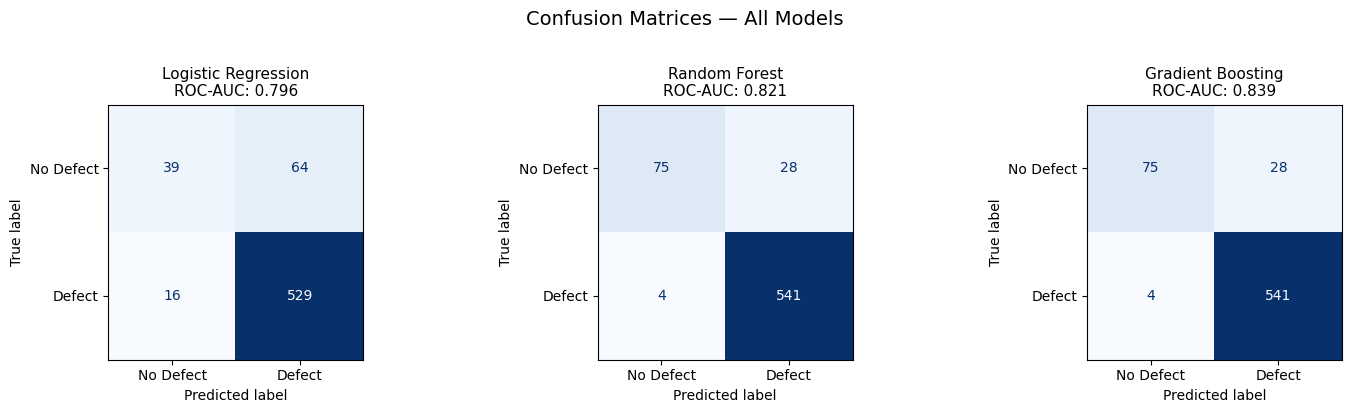

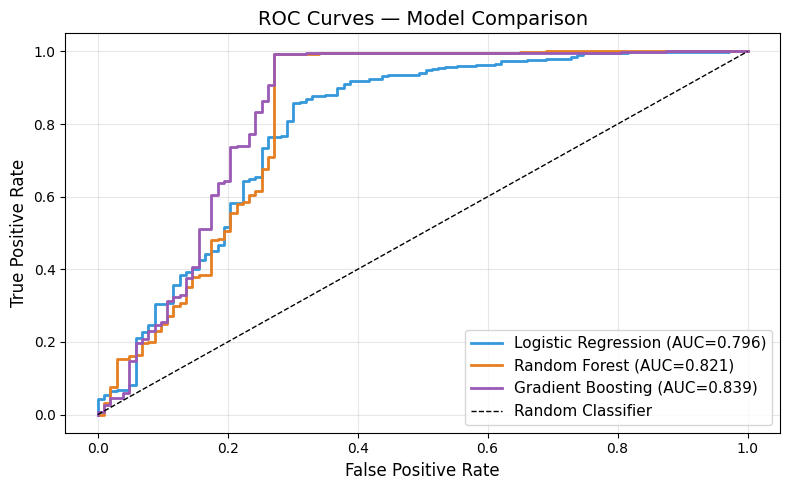


📋 Model Comparison Summary:
              Model ROC-AUC CV Mean CV Std
Logistic Regression  0.7960  0.8465 0.0046
      Random Forest  0.8209  0.8930 0.0217
  Gradient Boosting  0.8391  0.9046 0.0175


In [13]:
# CELL 7 — Model Comparison & Visualisation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect','Defect'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nROC-AUC: {res['roc_auc']:.3f}", fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(8, 5))
colors = ['#3498db', '#e67e22', '#9b59b6']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=color, lw=2)

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Model':     list(results.keys()),
    'ROC-AUC':   [f"{r['roc_auc']:.4f}" for r in results.values()],
    'CV Mean':   [f"{r['cv_mean']:.4f}" for r in results.values()],
    'CV Std':    [f"{r['cv_std']:.4f}"  for r in results.values()]
})
print("\n📋 Model Comparison Summary:")
print(summary_df.to_string(index=False))

🏆 Best Model: Gradient Boosting (ROC-AUC = 0.8391)


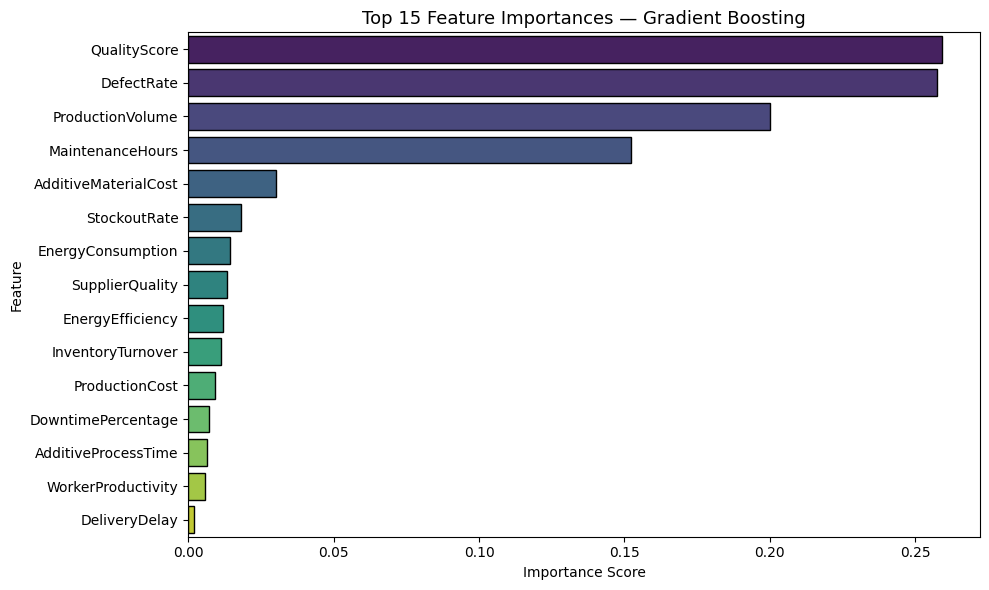


📌 Top 10 Features:
             Feature  Importance
        QualityScore    0.259322
          DefectRate    0.257439
    ProductionVolume    0.200064
    MaintenanceHours    0.152229
AdditiveMaterialCost    0.030071
        StockoutRate    0.017965
   EnergyConsumption    0.014404
     SupplierQuality    0.013361
    EnergyEfficiency    0.012030
   InventoryTurnover    0.011275


In [8]:
# CELL 8 — Select Best Model & Feature Importance

# Auto-select the best model by ROC-AUC
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_name]['model']
print(f"🏆 Best Model: {best_name} (ROC-AUC = {results[best_name]['roc_auc']:.4f})")

# Feature importance (tree models only)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature':    FEATURES,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature',
                palette='viridis', edgecolor='black')
    plt.title(f'Top 15 Feature Importances — {best_name}', fontsize=13)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print("\n📌 Top 10 Features:")
    print(importance_df.head(10).to_string(index=False))

elif best_name == "Logistic Regression":
    coef_df = pd.DataFrame({
        'Feature':     FEATURES,
        'Coefficient': best_model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    colors_coef = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
    sns.barplot(data=coef_df, x='Coefficient', y='Feature',
                palette=colors_coef, edgecolor='black')
    plt.axvline(0, color='black', lw=1)
    plt.title('Logistic Regression Coefficients (Top 15)', fontsize=13)
    plt.tight_layout()
    plt.show()

In [9]:
# CELL 9 — Generate Predictions on Full Dataset & Export

def assign_risk(prob):
    """Map defect probability to Low / Medium / High risk category."""
    if prob < 0.30:
        return 'Low'
    elif prob < 0.60:
        return 'Medium'
    else:
        return 'High'

# Run best model on entire dataset for export
X_full = df_model[FEATURES]

if best_name == "Logistic Regression":
    X_full_input = scaler.transform(X_full)
else:
    X_full_input = X_full

full_pred  = best_model.predict(X_full_input)
full_proba = best_model.predict_proba(X_full_input)[:, 1]

# Build export DataFrame
export_df = df.copy()
export_df['Predicted_Defect']    = full_pred
export_df['Defect_Probability']  = np.round(full_proba, 4)
export_df['Risk_Category']       = [assign_risk(p) for p in full_proba]

print("=== Export Preview (first 10 rows) ===")
print(export_df[['Predicted_Defect','Defect_Probability','Risk_Category']].head(10))

print("\n=== Risk Category Breakdown ===")
print(export_df['Risk_Category'].value_counts())

# Save and download
export_df.to_csv('manufacturing_predictions.csv', index=False)
files.download('manufacturing_predictions.csv')
print("\n✅ manufacturing_predictions.csv downloaded successfully!")

=== Export Preview (first 10 rows) ===
   Predicted_Defect  Defect_Probability Risk_Category
0                 1              0.9850          High
1                 1              0.9886          High
2                 1              0.9894          High
3                 1              0.9857          High
4                 1              0.9869          High
5                 1              0.9872          High
6                 1              0.9507          High
7                 1              0.9833          High
8                 1              0.9856          High
9                 0              0.0418           Low

=== Risk Category Breakdown ===
Risk_Category
High      2763
Low        425
Medium      52
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ manufacturing_predictions.csv downloaded successfully!


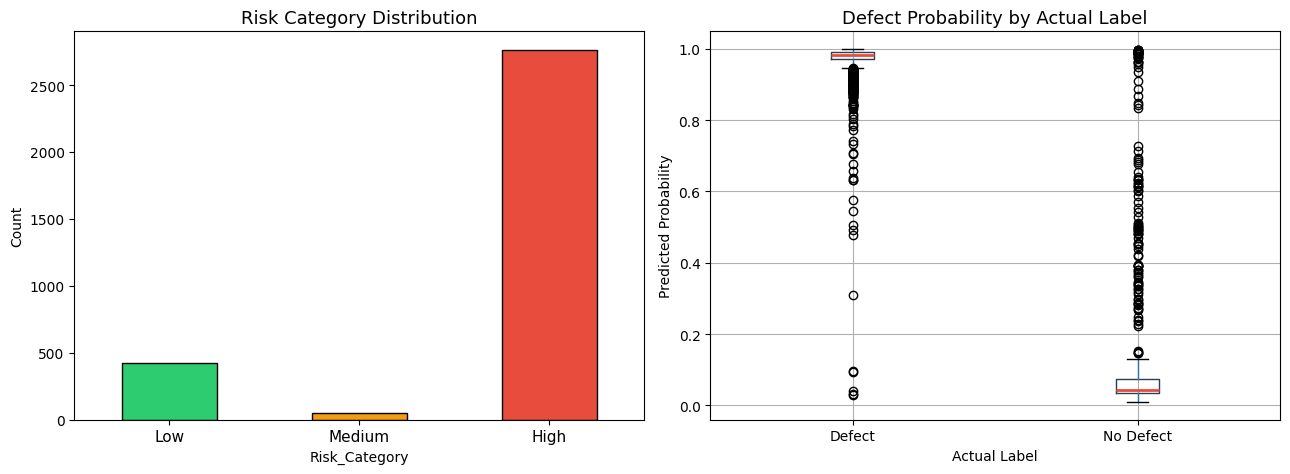


🎉 Pipeline complete! Your predictions have been exported to manufacturing_predictions.csv


In [10]:
# CELL 10 — Risk Category Visualisation

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Risk distribution
risk_counts = export_df['Risk_Category'].value_counts().reindex(['Low','Medium','High'])
risk_colors = ['#2ecc71', '#f39c12', '#e74c3c']
risk_counts.plot(kind='bar', ax=axes[0], color=risk_colors, edgecolor='black')
axes[0].set_title('Risk Category Distribution', fontsize=13)
axes[0].set_xticklabels(['Low','Medium','High'], rotation=0, fontsize=11)
axes[0].set_ylabel('Count')

# Probability distribution by actual defect
export_df['Actual'] = export_df['DefectStatus'].map({0:'No Defect', 1:'Defect'}) # Changed 'Defect' to 'DefectStatus'
export_df.boxplot(column='Defect_Probability', by='Actual', ax=axes[1],
                  boxprops=dict(color='#2c3e50'),
                  medianprops=dict(color='#e74c3c', lw=2))
axes[1].set_title('Defect Probability by Actual Label', fontsize=13)
axes[1].set_xlabel('Actual Label')
axes[1].set_ylabel('Predicted Probability')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n🎉 Pipeline complete! Your predictions have been exported to manufacturing_predictions.csv")